# Model Output Notebook

<img style="float:center;" src="https://arcticexpansion.vse.gmu.edu/sites/arcticexpansion.vsnet.gmu.edu/files/images/header5d2.png" width=600px>

### ADCIRC-SWAN Output


### Initialize Libraries

In [1]:
import warnings;            import os
import pathlib as pl;       import string
import calendar;            import numpy as np
import pandas as pd;        import xarray as xr
import ruptures as rpt;     import matplotlib.pyplot as plt
import matplotlib as mpl;   import cartopy.crs as ccrs
import cartopy.feature as cfeature
from dask.distributed import Client, LocalCluster
from scipy.stats import pearsonr, genextreme, gumbel_r
from statsmodels.tsa.stattools import adfuller, kpss
from dask import delayed, compute
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from statsmodels.tools.sm_exceptions import HypothesisTestWarning
warnings.filterwarnings("ignore")

source $HOME/miniforge3/bin/activate

salloc --ntasks=5 --nodes=1 --partition=normal --time=10:00:00

### Defined Functions

#### Data for this exercise can be found here
https://doi.org/10.17603/ds2-h0fw-2p96

Download the swan_HS.63.nc from one of the 4 folders

---

In [2]:
def compute_keep_idx(sample_path, min_depth, max_depth, bbox=None):
    """
    Return indices of nodes whose depth ∈ [min_depth, max_depth],
    optionally also within (min_x, max_x, min_y, max_y).
    """
    ds = xr.open_dataset(sample_path, engine="netcdf4", mask_and_scale=False)
    depth = ds.depth.values
    fv    = ds.depth.encoding.get("_FillValue", None)

    mask = np.ones_like(depth, dtype=bool)
    if fv is not None:
        mask &= (depth != fv)
    mask &= (depth >= min_depth) & (depth <= max_depth)

    if bbox is not None:
        min_x, max_x, min_y, max_y = bbox
        x, y = ds.x.values, ds.y.values
        mask &= (x >= min_x) & (x <= max_x) & (y >= min_y) & (y <= max_y)

    ds.close()
    return np.where(mask)[0]


def preprocess(ds):
    """Keep only the spin‑up‑free calendar year & shallow nodes."""
    ds = ds.assign_coords(time=pd.to_datetime(ds.time.values))
    year = ds.time.dt.year.values[600]
    mask = ds.time.dt.year == year
    return ds.isel(time=mask, node=keep_idx)


# ─── Change-point detection function ──────────────────────────────────────────
def detect_cp_annual(y, years_array, n_bkps=1):
    """
    Identify one change-point in a 1D annual series using ruptures.
    Returns the corresponding year or NaN if no valid break.
    """
    # need at least 5 valid points
    if np.sum(~np.isnan(y)) < 5:
        return np.nan

    algo = rpt.Binseg(model='rbf').fit(y.reshape(-1, 1))
    bkps = algo.predict(n_bkps=n_bkps)  # e.g., [idx]
    cp   = bkps[0]

    # ensure break is interior
    if 0 < cp < len(years_array):
        return years_array[cp]
    return np.nan

def test_stationarity(arr, alpha=0.05):
    """
    Returns (is_stationary, p_adf, p_kpss) for a 1D array.
    ADF stationary if p_adf < alpha; KPSS stationary if p_kpss > alpha.
    """
    # ADF
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", HypothesisTestWarning)
        try:
            p_adf = adfuller(arr, autolag='AIC')[1]
        except Exception:
            p_adf = 0.0
    # KPSS
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", HypothesisTestWarning)
        try:
            p_kpss = kpss(arr, regression='c', nlags='auto')[1]
        except Exception:
            p_kpss = 1.0

    p_adf  = min(max(p_adf, 0.0), 1.0)
    p_kpss = min(max(p_kpss, 0.0), 1.0)
    return (p_adf < alpha) and (p_kpss > alpha), p_adf, p_kpss


def make_labels(n):
    """Generate ‘a.’, ‘b.’ … ‘z.’, ‘aa.’, … for n panels."""
    labels = []
    alphabet = string.ascii_lowercase
    i = 0
    while len(labels) < n:
        s, x = '', i
        while True:
            s = alphabet[x % 26] + s
            x = x // 26 - 1
            if x < 0:
                break
        labels.append(s + '.')
        i += 1
    return labels


In [3]:
df_season = pd.read_csv("hs_seasonal_daily.csv")#, parse_dates=["onset_date","end_date"])
summary = df_season.groupby("node")["duration_days"].agg(["min","max"])

# condition 1: always >= 360 days
cond_all_year = summary["min"] >= 300

# condition 2: always <= 15 days
cond_no_season = summary["min"] <= 15

bad_nodes = summary[cond_all_year | cond_no_season].index.tolist()
print(f"Removing {len(bad_nodes)} unrealistic nodes "
      f"({sum(cond_all_year)} always year-round, {sum(cond_no_season)} never seasonal)")

# filter
df_season = df_season[~df_season["node"].isin(bad_nodes)].copy()

Removing 54322 unrealistic nodes (11816 always year-round, 42506 never seasonal)


In [4]:
df_season["duration_days"] = pd.to_numeric(df_season["duration_days"], errors="coerce")

# keep only 1980 and 2024
sub = df_season[df_season["year"].isin([1980, 2024])][["node", "year", "duration_days", "lat", "lon"]]

# pivot so each node has both years' durations
pivot = sub.pivot_table(index=["node", "lat", "lon"], columns="year", values="duration_days", aggfunc="median")

# compute difference (2024 - 1980)
pivot["duration_diff"] = pivot[2024] - pivot[1980]
#pivot['duration_diff'].loc[pivot['duration_diff']<0] = np.nan
diff_raw = pivot[2024] - pivot[1980]
bad_mask = diff_raw < 0
bad_nodes = pd.Index(pivot.index.get_level_values("node")[bad_mask]).unique().tolist()

# optional: inspect/save removed nodes
# pd.Series(bad_nodes, name="node").to_csv("nodes_removed_negative_duration_diff.csv", index=False)

# remove from df_season
df_season = df_season[~df_season["node"].isin(bad_nodes)].copy()

In [5]:
keep_idx = df_season['node'].unique()

In [6]:
# ─── User‑set parameters ──────────────────────────────────────────────────────
lat1, lat2 = 56, 75
lon1, lon2 = -168.5, -140
root       = '/scratch/tmiesse/project/data4spatial'
YEARS      = range(1980, 2025)
MIN_DEPTH  = 7.5
MAX_DEPTH  = 15
bbox       = (lon1, lon2, lat1, lat2)

# compute shallow nodes index
sample_path = f"{root}/2023/swan_HS.63.cf.nc"
#keep_idx    = compute_keep_idx(sample_path, MIN_DEPTH, MAX_DEPTH, bbox)
print(f"Keeping {len(keep_idx)} nodes")

Keeping 174790 nodes


In [7]:

# ─── Spin up a Dask cluster ───────────────────────────────────────────────────
n_workers   = int(os.environ.get("SLURM_NTASKS", "45"))
mem_per_cpu = os.environ.get("SLURM_MEM_PER_CPU", "72GB")
cluster     = LocalCluster(
    n_workers=n_workers,
    threads_per_worker=1,
    processes=True,
    memory_limit=mem_per_cpu
)
client = Client(cluster)
print(client)

<Client: 'tcp://127.0.0.1:36643' processes=45 threads=45, memory=2.95 TiB>


In [33]:
client.close()

In [8]:
paths = [str(pl.Path(root)/str(y)/"swan_HS.63.cf.nc") for y in YEARS]
ds_all = xr.open_mfdataset(
    paths,
    engine="h5netcdf",
    mask_and_scale=True,
    decode_cf=True,
    preprocess=preprocess,
    combine="nested",
    concat_dim="time",
    data_vars=['swan_HS'],               # only load zeta
    chunks={'time': 24},# chunk on both dims
    coords="minimal")   # minimal coords → time, node, x, y

In [9]:
times = ds_all.time.values
hs = ds_all.swan_HS
hs = hs.assign_coords(node=("node", keep_idx))
hs = ds_all.swan_HS.values
x = ds_all.x.values
y = ds_all.y.values

In [10]:
time_idx = pd.to_datetime(times)
years = np.unique(time_idx.year)

In [20]:
nodes_to_test = list(pd.unique(df_season["node"]))[:2000]

if not np.issubdtype(df_season["onset_date"].dtype, np.datetime64):
    df_season["onset_date"] = pd.to_datetime(df_season["onset_date"], errors="coerce")
if not np.issubdtype(df_season["end_date"].dtype, np.datetime64):
    df_season["end_date"]   = pd.to_datetime(df_season["end_date"], errors="coerce")

node_to_col = {int(k): i for i, k in enumerate(keep_idx)}
time_idx = pd.to_datetime(times)

records = []
sub = df_season[df_season["node"].isin(nodes_to_test)].dropna(subset=["onset_date","end_date"])

for r in sub.itertuples(index=False):
    n = int(r.node)
    col = node_to_col.get(n)
    if col is None:
        continue

    t0, t1 = pd.Timestamp(r.onset_date), pd.Timestamp(r.end_date)
    if (not np.isfinite(t0.value)) or (not np.isfinite(t1.value)) or (t1 < t0):
        continue

    mask = (time_idx >= t0) & (time_idx <= t1)
    if not mask.any():
        continue

    vals = hs[mask, col]
    if not np.any(np.isfinite(vals)):
        continue

    p90  = float(np.nanpercentile(vals, 90))
    p99  = float(np.nanpercentile(vals, 99))
    vmax = float(np.nanmax(vals))

    i_max = int(np.nanargmax(vals))
    t_max = pd.Timestamp(time_idx[mask][i_max])
    doy_max = int(t_max.dayofyear)

    records.append({
        "node": n, "year": int(r.year),
        "hs_p90": p90, "hs_p99": p99, "hs_max": vmax,
        "time_max": t_max, "doy_max": doy_max
    })

out = pd.DataFrame.from_records(records).sort_values(["node","year"]).reset_index(drop=True)
print(out.head())

    node  year    hs_p90    hs_p99    hs_max            time_max  doy_max
0  37846  1980  0.608047  0.954760  1.318400 1980-06-20 04:59:55      172
1  37846  1981  0.606476  1.062051  1.443336 1981-11-26 08:59:55      330
2  37846  1982  0.732146  1.150334  1.579628 1982-09-16 20:00:00      259
3  37846  1983  0.612549  1.112239  1.807017 1983-09-30 02:00:00      273
4  37846  1984  0.455024  0.901195  1.551952 1984-12-16 01:59:55      351


In [29]:
from dask import delayed, compute
def _robust_p90_p99(a):
    v = np.asarray(a, dtype=float)
    v = v[np.isfinite(v)]
    if v.size == 0:
        return np.nan, np.nan
    try:
        p = np.quantile(v, [0.90, 0.99], method="linear")
    except TypeError:  # NumPy < 1.22
        p = np.quantile(v, [0.90, 0.99], interpolation="linear")
    if p[1] < p[0]:
        w = np.sort(v)
        k90 = max(0, int(np.ceil(0.90 * w.size)) - 1)
        k99 = max(0, int(np.ceil(0.99 * w.size)) - 1)
        p = np.array([w[k90], w[k99]])
    return float(p[0]), float(p[1])

def compute_magnitudes_dask(df_season, nodes_to_test, time_idx, hs, node_to_col,
                            chunk_size=20000):
    # Filter & normalize
    sub = df_season[df_season["node"].isin(nodes_to_test)].dropna(
        subset=["onset_date", "end_date"]
    ).copy()

    if not np.issubdtype(sub["onset_date"].dtype, np.datetime64):
        sub["onset_date"] = pd.to_datetime(sub["onset_date"], errors="coerce")
    if not np.issubdtype(sub["end_date"].dtype, np.datetime64):
        sub["end_date"]   = pd.to_datetime(sub["end_date"],   errors="coerce")

    t64   = pd.to_datetime(time_idx).to_numpy(dtype="datetime64[ns]")
    onset = sub["onset_date"].to_numpy(dtype="datetime64[ns]")
    end   = sub["end_date"].to_numpy(dtype="datetime64[ns]")
    nodes = sub["node"].to_numpy()
    years = sub["year"].to_numpy()
    lats  = sub["lat"].to_numpy()
    lons  = sub["lon"].to_numpy()

    t0 = np.searchsorted(t64, onset, side="left").astype(np.int64)
    t1 = np.searchsorted(t64, end,   side="right").astype(np.int64) - 1
    t0 = np.clip(t0, 0, len(t64)-1)
    t1 = np.clip(t1, 0, len(t64)-1)

    cols = pd.Series(nodes).map(node_to_col).to_numpy()
    valid = (~pd.isna(cols)) & (t1 >= t0)
    if not valid.any():
        return pd.DataFrame(columns=[
            "node","year","lat","lon","hs_p90","hs_p99","hs_max","time_max","doy_max"
        ])

    t0 = t0[valid]; t1 = t1[valid]
    cols = cols[valid].astype(np.int64)
    nodes = nodes[valid]; years = years[valid]
    lats = lats[valid]; lons = lons[valid]

    doy_lookup = pd.to_datetime(t64).dayofyear.to_numpy(np.int32)

    def _process_chunk(a0, a1, ac, an, ay, alat, alon):
        out = {
            "node": [], "year": [], "lat": [], "lon": [],
            "hs_p90": [], "hs_p99": [], "hs_max": [],
            "time_max_idx": [], "doy_max": []
        }
        for s, e, c, n, y, la, lo in zip(a0, a1, ac, an, ay, alat, alon):
            seg = hs[s:e+1, c]
            if seg.size == 0 or not np.isfinite(seg).any():
                continue
            p90, p99 = _robust_p90_p99(seg)
            vmax = np.nanmax(seg)
            imax = int(np.nanargmax(seg))
            t_abs = s + imax
            out["node"].append(int(n))
            out["year"].append(int(y))
            out["lat"].append(float(la))
            out["lon"].append(float(lo))
            out["hs_p90"].append(p90)
            out["hs_p99"].append(p99)
            out["hs_max"].append(float(vmax))
            out["time_max_idx"].append(int(t_abs))
            out["doy_max"].append(int(doy_lookup[t_abs]))
        return pd.DataFrame(out)

    tasks = []
    N = len(t0)
    for start in range(0, N, chunk_size):
        stop = min(start + chunk_size, N)
        tasks.append(delayed(_process_chunk)(
            t0[start:stop], t1[start:stop], cols[start:stop],
            nodes[start:stop], years[start:stop],
            lats[start:stop], lons[start:stop]
        ))

    parts = compute(*tasks)
    res = pd.concat(parts, ignore_index=True)
    res["time_max"] = pd.to_datetime(t64[res["time_max_idx"].to_numpy()], errors="coerce")
    res = res.drop(columns=["time_max_idx"]).sort_values(["node","year"]).reset_index(drop=True)
    return res

In [35]:
sub_nodes = list(pd.unique(df_season["node"]))[:]
# Call the optimized function
out = compute_magnitudes_dask(
    df_season=df_season,
    nodes_to_test=sub_nodes,
    time_idx=time_idx,
    hs=hs,                      # hs must be a NumPy array (not xarray.DataArray)
    node_to_col=node_to_col,
    chunk_size=100            # adjust based on available memory
)

In [36]:
out.to_csv("hs_seasonal_stats.csv", index=False)

In [17]:
out = pd.read_csv("hs_seasonal_stats.csv")

In [18]:
import geopandas as gpd
from shapely.geometry import Point

In [119]:
target_sea = "Beaufort Sea"  # ← change as needed
seas = gpd.read_file("/scratch/tmiesse/project/world_seas/world_seas.shp")
name_col = next(c for c in seas.columns if str(c).lower() in ("name","name_en","sea_name","seas","sea"))
seas_target = seas[seas[name_col] == target_sea].to_crs(4326)

nodes_df = out[["node","lat","lon"]].drop_duplicates("node").reset_index(drop=True)
g_nodes = gpd.GeoDataFrame(
    nodes_df, geometry=[Point(xy) for xy in zip(nodes_df["lon"], nodes_df["lat"])], crs="EPSG:4326"
)
sea_nodes = set(gpd.sjoin(g_nodes, seas_target[[name_col,"geometry"]], predicate="within", how="inner")["node"].astype(int))


In [120]:
# --- ensure node->column map exists (do not overwrite if already present) ---
try:
    node_to_col  # noqa: F821
except NameError:
    if 'keep_idx' in locals():
        node_to_col = {int(k): i for i, k in enumerate(np.asarray(keep_idx))}
    elif 'ds_all' in locals():
        node_ids = np.asarray(getattr(ds_all, "node", ds_all.swan_HS["node"]).values)
        node_to_col = {int(k): i for i, k in enumerate(node_ids)}
    else:
        raise NameError("Define node_to_col (or keep_idx/ds_all) to map node IDs to hs columns.")

# --- select only columns for this sea ---
cols = [node_to_col.get(int(n)) for n in sea_nodes if node_to_col.get(int(n)) is not None]
if not cols:
    raise ValueError(f"No hs columns found for nodes in {target_sea}.")

# --- time pieces; drop Feb 29 to stick to 365-day axis ---
ti = pd.to_datetime(time_idx)
years_all = ti.year.to_numpy()
doys_all  = ti.dayofyear.to_numpy()
is_feb29  = (ti.month.values == 2) & (ti.day.values == 29)

# --- define five 9-year groups (start at 1980 if present, else from min year) ---
start_year = 1980 #if (years_all.min() <= 1980 <= years_all.max()) else int(years_all.min())

edges = np.arange(1980, 2025, 9)  # stops before 2025 → [1980, 1995, 2010, 2025)
groups = [(1980,1990),(2014,2024)]#,(2010,2024)]#[(int(edges[i]), int(edges[i+1] - 1)) for i in range(len(edges) - 1)]

In [121]:
# --- helper: remove waves within 50-day window ---
def remove_close_waves(arr, threshold=50):
    arr = np.asarray(arr, float)
    if arr.size == 0:
        return arr
    valid_idx = np.where(arr > 0)[0]
    if len(valid_idx) == 0:
        return arr
    keep = np.ones_like(valid_idx, bool)
    last_idx = -1e9
    for i, idx in enumerate(valid_idx):
        if idx - last_idx <= threshold:
            keep[i] = False
        else:
            last_idx = idx
    arr[:] = 0
    arr[valid_idx[keep]] = arr[valid_idx[keep]]
    return arr

# --- helpers ---
def _q90_q99(arr):
    v = np.asarray(arr, float)
    v = v[np.isfinite(v)]
    if v.size < 5:
        return np.nan, np.nan
    try:
        q = np.quantile(v, [0.5, 0.75], method="linear")
    except TypeError:
        q = np.quantile(v, [0.5, 0.75], interpolation="linear")
    q[1] = max(q[1], q[0])
    return float(q[0]), float(q[1])

# --- compute daily p90/p99 for each 9-year group ---

hs_np = np.asarray(hs)
p90 = np.full((len(groups), 365), np.nan)
p99 = np.full((len(groups), 365), np.nan)

for gi, (g0, g1) in enumerate(groups):
    gmask_time = (years_all >= g0) & (years_all <= g1) & (~is_feb29)
    if not gmask_time.any():
        continue
    for d in range(1, 366):
        tmask = gmask_time & (doys_all == d)
        if not tmask.any():
            continue

        seg = np.asarray(hs[tmask][:, cols]).ravel()
        seg = np.where(np.isnan(seg), 0, seg)

        if d <= 25:
            # zero out all waves within the first 50 days of the year
            seg[:] = 0.0

        finite = np.isfinite(seg)
        if not finite.any():
            continue

        seg = seg[finite]
        if seg.size < 5:
            continue

        try:
            q = np.quantile(seg, [0.5, 0.75], method="linear")
        except TypeError:
            q = np.quantile(seg, [0.5, 0.75], interpolation="linear")
        q[1] = max(q[1], q[0])
        p90[gi, d-1] = float(q[0])
        p99[gi, d-1] = float(q[1])

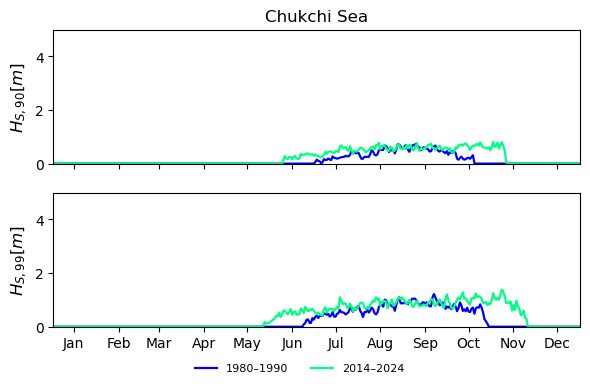

In [107]:
x = np.arange(1, 366)
labels = [f"{a}–{b}" for a, b in groups]
cmap = plt.cm.winter; norm = plt.Normalize(0, len(groups)-1)

fig, axes = plt.subplots(2, 1, figsize=(6, 4), sharex=True)
for gi in range(len(groups)):
    axes[0].plot(x, p90[gi], lw=1.6, color=cmap(norm(gi)), label=labels[gi])
    axes[1].plot(x, p99[gi], lw=1.6, color=cmap(norm(gi)), label=labels[gi])

axes[0].set_title(f"{target_sea}")
#axes[1].set_title(f"{target_sea}: Daily 99th percentile (9-year groups)")

axes[0].set_ylabel("$H_{S,90} [m]$", fontsize=12)
axes[1].set_ylabel("$H_{S,99} [m]$",fontsize=12)

month_ticks = [15, 46, 74, 105, 135, 166, 196, 227, 258, 288, 319, 349]
month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
axes[0].set_xticks(month_ticks),axes[1].set_xticks(month_ticks)
axes[0].set_xlim(1, 365), axes[1].set_xlim(1, 365)
axes[0].set_ylim(0, 5), axes[1].set_ylim(0, 5)
axes[1].set_xticklabels(month_labels)
handles, _ = axes[0].get_legend_handles_labels()
axes[1].legend(loc="upper left", fontsize=8, frameon=False, ncol=3, bbox_to_anchor=(0.25, -0.2))
plt.tight_layout()
# plt.savefig(f"{target_sea.replace(' ','_').lower()}_daily_p90_p99_9yr_groups.png", dpi=300)
plt.show()


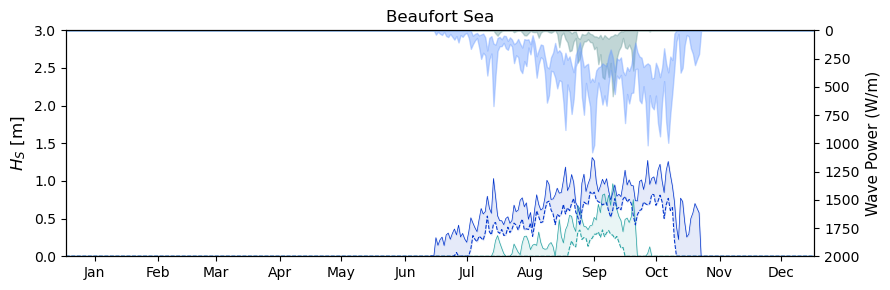

In [122]:
import matplotlib.ticker as mticker

x = np.arange(1, 366)
labels = [f"{a}–{b}" for a, b in groups]
colors = ['#29a3a3', '#0033cc']
colors2= ['#669999','#6699ff']
fig, ax1 = plt.subplots(figsize=(9, 3))
ax2 = ax1.twinx()

density = 1025
g = 9.81

# --- main wave height percentiles ---
for gi in range(len(groups)):
    ax1.plot(x, p90[gi], lw=.75, color=colors[gi], linestyle='--', label='$H_{S,50}$ ' + labels[gi])
    ax1.plot(x, p99[gi], lw=.5, color=colors[gi], label='$H_{S,75}$ ' + labels[gi])
    ax1.fill_between(x, p90[gi], p99[gi], color=colors[gi], alpha=0.1)
    power1 = (1 / 16) * g * density * (p90[gi] ** 2)
    #ax2.plot(x, power1, lw=.6, color=colors2[gi], linestyle='--', label='$P_{50}$ ' + labels[gi])
    power2 = (1 / 16) * g * density * (p99[gi] ** 2)
    #ax2.plot(x, power2, lw=.6, color=colors2[gi], linestyle='-', label='$P_{75}$ ' + labels[gi])
    ax2.fill_between(x, power1, power2, color=colors2[gi], alpha=0.4)
    # --- compute and plot mirrored wave power ---

power11 = (1 / 16) * g * density * (p90[1] ** 2)
pdiff1 = np.abs(power11 - power1)

power22 = (1 / 16) * g * density * (p99[1] ** 2)
pdiff2 = np.abs(power22 - power2)

# --- mirror the wave power axis visually but keep positive labels ---
ax2.invert_yaxis()
ax2.set_ylim(2000, 0)  # visually flipped
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"{abs(int(x))}"))  # force positive labels

# --- labels and formatting ---
ax1.set_title(f"{target_sea}")
ax1.set_ylabel("$H_{S}$ [m]", fontsize=12)
ax2.set_ylabel("Wave Power (W/m)", fontsize=11, color='black')
ax2.tick_params(axis='y', colors='black')

# --- x-axis setup ---
month_ticks = [15, 46, 74, 105, 135, 166, 196, 227, 258, 288, 319, 349]
month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
ax1.set_xticks(month_ticks)
ax1.set_xticklabels(month_labels)
ax1.set_xlim(1, 365)
ax1.set_ylim(0, 3)

# --- legends ---
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
#ax1.legend(handles1 + handles2, labels1 + labels2,
#           loc="upper left", fontsize=9, frameon=False, ncol=4, bbox_to_anchor=(0.1, -0.15))

plt.tight_layout()
plt.savefig(f"/scratch/tmiesse/project/satellite/figures/filled_hs_{target_sea.replace(' ','_').lower()}_mirrored_power_positive.png", dpi=720)
plt.show()

_____________________________________